# hlth_silc_08b robustness check

This section compares the primary outcome with the persons-with-need denominator indicator for 2021-2025.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.formula.api as smf

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / 'src'))
from eurostat_api import build_country_year_table, download_json, eurostat_url

sns.set_theme(style='whitegrid')
OUTPUTS_DIR = PROJECT_ROOT / 'outputs'
FIGURES_DIR = OUTPUTS_DIR / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
RAW_DIR = PROJECT_ROOT / 'data' / 'raw'
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
YEARS_08B = range(2021, 2026)
panel = pd.read_csv(PROCESSED_DIR / 'panel_skeleton.csv')
panel.shape

(608, 9)

In [2]:
params_08b = {
    'unit': 'PC',
    'rskpovth': 'TOTAL',
    'reason': 'TXP_TFAR_WLIST',
    'age': 'Y_GE16',
    'sex': 'T',
    'time': [str(year) for year in YEARS_08B],
}
raw_path = RAW_DIR / 'hlth_silc_08b_unmet_need_2021_2025_phase4.json'
data_08b = download_json('hlth_silc_08b', params_08b, raw_path)
outcome_08b = build_country_year_table(data_08b, 'unmet_need_pc_08b', YEARS_08B)
outcome_08b = outcome_08b[['geo', 'year', 'unmet_need_pc_08b', 'status']].rename(columns={'status': 'status_08b'})
outcome_08b.to_csv(PROCESSED_DIR / 'country_year_outcome_08b.csv', index=False)
(OUTPUTS_DIR / 'hlth_silc_08b_phase4_api_url.txt').write_text(eurostat_url('hlth_silc_08b', params_08b), encoding='utf-8')
outcome_08b.head()

,geo,year,unmet_need_pc_08b,status_08b
0,AL,2021,13.7,
1,AL,2022,13.5,
2,AL,2023,13.8,
3,AT,2021,0.6,
4,AT,2022,1.1,


In [3]:
primary_08 = panel.loc[panel['year'].between(2021, 2025), ['geo', 'year', 'unmet_need_pc']].rename(columns={'unmet_need_pc': 'unmet_need_pc_08'})
comparison = primary_08.merge(outcome_08b[['geo', 'year', 'unmet_need_pc_08b']], on=['geo', 'year'], how='inner')
comparison['difference_08b_minus_08'] = comparison['unmet_need_pc_08b'] - comparison['unmet_need_pc_08']
comparison.to_csv(OUTPUTS_DIR / '08b_common_country_years.csv', index=False)
country_avg = comparison.groupby('geo', as_index=False).agg(
    unmet_need_pc_08=('unmet_need_pc_08', 'mean'),
    unmet_need_pc_08b=('unmet_need_pc_08b', 'mean'),
    difference_08b_minus_08=('difference_08b_minus_08', 'mean'),
).sort_values('difference_08b_minus_08', ascending=False)
country_avg.to_csv(OUTPUTS_DIR / '08b_country_average_comparison.csv', index=False)
country_avg.head()

,geo,unmet_need_pc_08,unmet_need_pc_08b,difference_08b_minus_08
10,EL,10.12,18.400000,8.280000
29,RS,4.68,8.420000,3.740000
12,FI,7.02,10.300000,3.280000
0,AL,10.40,13.666667,3.266667
28,RO,3.92,6.860000,2.940000


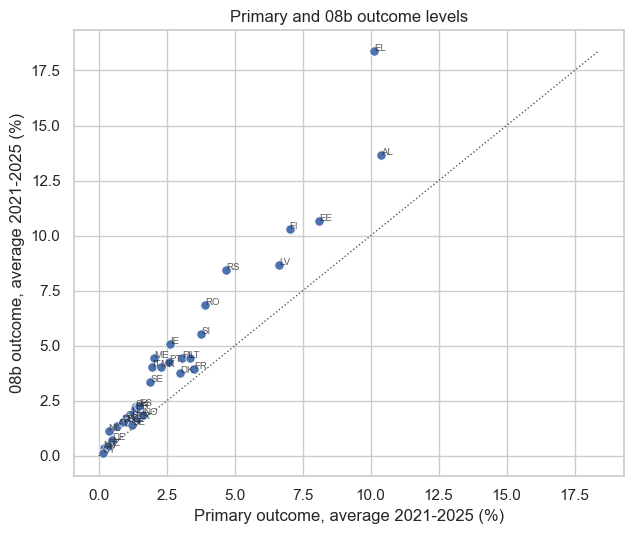

In [4]:
fig, ax = plt.subplots(figsize=(6.5, 5.5))
sns.scatterplot(data=country_avg, x='unmet_need_pc_08', y='unmet_need_pc_08b', s=45, ax=ax)
axis_max = max(country_avg['unmet_need_pc_08'].max(), country_avg['unmet_need_pc_08b'].max())
ax.plot([0, axis_max], [0, axis_max], color='0.35', linestyle=':', linewidth=1)
for _, row in country_avg.iterrows():
    ax.text(row['unmet_need_pc_08'], row['unmet_need_pc_08b'], row['geo'], fontsize=7, alpha=0.75)
ax.set_xlabel('Primary outcome, average 2021-2025 (%)')
ax.set_ylabel('08b outcome, average 2021-2025 (%)')
ax.set_title('Primary and 08b outcome levels')
fig.tight_layout()
fig.savefig(FIGURES_DIR / '08b_vs_08_scatter.png', dpi=180)
plt.show()

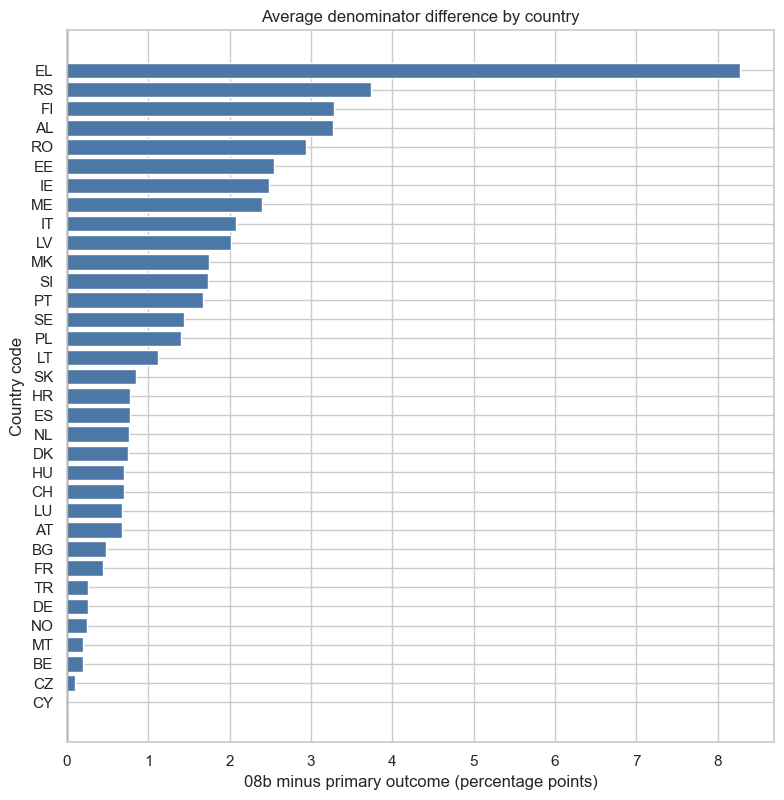

In [5]:
plot_data = country_avg.sort_values('difference_08b_minus_08')
fig, ax = plt.subplots(figsize=(8, max(6, 0.24 * len(plot_data))))
ax.barh(plot_data['geo'], plot_data['difference_08b_minus_08'], color='#4c78a8')
ax.axvline(0, color='0.25', linewidth=1)
ax.set_xlabel('08b minus primary outcome (percentage points)')
ax.set_ylabel('Country code')
ax.set_title('Average denominator difference by country')
fig.tight_layout()
fig.savefig(FIGURES_DIR / '08b_minus_08_difference_by_country.png', dpi=180)
plt.show()

In [6]:
model_panel = panel.merge(outcome_08b[['geo', 'year', 'unmet_need_pc_08b']], on=['geo', 'year'], how='inner')
model_panel = model_panel.rename(columns={'unmet_need_pc': 'unmet_need_pc_08'})
model_panel['log_gdp_per_capita'] = np.log(model_panel['gdp_per_capita_eur'])
model_vars = ['geo', 'year', 'unmet_need_pc_08', 'unmet_need_pc_08b', 'log_gdp_per_capita', 'unemployment_rate_pc', 'poverty_or_social_exclusion_pc']
model_data = model_panel[model_vars].dropna().copy()
formula_08 = 'unmet_need_pc_08 ~ log_gdp_per_capita + unemployment_rate_pc + poverty_or_social_exclusion_pc'
formula_08b = 'unmet_need_pc_08b ~ log_gdp_per_capita + unemployment_rate_pc + poverty_or_social_exclusion_pc'
result_08 = smf.ols(formula_08, data=model_data).fit(cov_type='HC1')
result_08b = smf.ols(formula_08b, data=model_data).fit(cov_type='HC1')
model_data.shape

(147, 7)

In [7]:
def tidy_result(result, outcome_name):
    return pd.DataFrame({
        'outcome': outcome_name,
        'variable': result.params.index,
        'estimate': result.params.values,
        'standard_error': result.bse.values,
        't_stat': result.tvalues.values,
        'p_value': result.pvalues.values,
    }).round(4)

table_08 = tidy_result(result_08, 'unmet_need_pc_08')
table_08b = tidy_result(result_08b, 'unmet_need_pc_08b')
coef_table = pd.concat([table_08, table_08b], ignore_index=True)
coef_table.to_csv(OUTPUTS_DIR / 'table_08b_robustness_models.csv', index=False)
coef_table

,outcome,variable,estimate,standard_error,t_stat,p_value
0,unmet_need_pc_08,Intercept,4.0434,2.8847,1.4017,0.1610
1,unmet_need_pc_08,log_gdp_per_capita,-0.3291,0.2336,-1.4088,0.1589
2,unmet_need_pc_08,unemployment_rate_pc,0.3149,0.1002,3.1413,0.0017
3,unmet_need_pc_08,poverty_or_social_exclusion_pc,-0.0039,0.0445,-0.0888,0.9293
4,unmet_need_pc_08b,Intercept,4.9479,4.6977,1.0533,0.2922
5,unmet_need_pc_08b,log_gdp_per_capita,-0.4428,0.3812,-1.1615,0.2454
6,unmet_need_pc_08b,unemployment_rate_pc,0.5504,0.1661,3.3127,0.0009
7,unmet_need_pc_08b,poverty_or_social_exclusion_pc,0.0067,0.0681,0.0977,0.9222


In [8]:
mean_08 = comparison['unmet_need_pc_08'].mean()
mean_08b = comparison['unmet_need_pc_08b'].mean()
mean_diff = comparison['difference_08b_minus_08'].mean()
control_terms = ['log_gdp_per_capita', 'unemployment_rate_pc', 'poverty_or_social_exclusion_pc']
same_sign = []
for term in control_terms:
    sign_08 = np.sign(result_08.params[term])
    sign_08b = np.sign(result_08b.params[term])
    same_sign.append(term if sign_08 == sign_08b else None)
same_sign = [term for term in same_sign if term is not None]
summary = (
    '# 08b robustness summary\n\n'
    f'The comparison uses {len(comparison)} overlapping country-year cells from 2021-2025. '
    f'The primary outcome has an average level of {mean_08:.2f} percent, while the 08b outcome has an average level of {mean_08b:.2f} percent. '
    f'The average 08b minus primary difference is {mean_diff:.2f} percentage points.\n\n'
    f'The simple pooled models use {len(model_data)} complete rows. '
    f'The same coefficient sign appears for {len(same_sign)} of the {len(control_terms)} shared controls: '
    + (', '.join(same_sign) if same_sign else 'none')
    + '.\n\nThis is a denominator robustness and interpretation check. It is not a new core model.\n'
)
(OUTPUTS_DIR / '08b_robustness_summary.md').write_text(summary, encoding='utf-8')
summary

'# 08b robustness summary\n\nThe comparison uses 154 overlapping country-year cells from 2021-2025. The primary outcome has an average level of 2.67 percent, while the 08b outcome has an average level of 4.16 percent. The average 08b minus primary difference is 1.49 percentage points.\n\nThe simple pooled models use 147 complete rows. The same coefficient sign appears for 2 of the 3 shared controls: log_gdp_per_capita, unemployment_rate_pc.\n\nThis is a denominator robustness and interpretation check. It is not a new core model.\n'